In [52]:
import os
import pandas as pd
import numpy as np

def feature_extraction(scenario, method, threshold, ref_metric):
    folder_path = os.path.join("segments", scenario)
    if method.startswith("vwcd"):
        file_name = f"{method}_{ref_metric}_{threshold}.csv"
    else:
        file_name = f"{method}_{ref_metric}.csv"
    input_path = os.path.join(folder_path, file_name)
    
    if not os.path.exists(input_path):
        print(f"Erro: Arquivo {input_path} not found.")
        return pd.DataFrame()
    
    df = pd.read_csv(input_path)
    
    df = df[df['n_points'] >= 6].copy()
    
    df['series_id'] = df['client'] + "_" + df['server'] + "_" + df['block'].astype(str)
    
    series_counts = df.groupby('series_id').size()
    series_with_changes = series_counts[series_counts > 1].index
    df_filtered = df[df['series_id'].isin(series_with_changes)].copy()
    
    df_filtered = df_filtered.sort_values(['client', 'server', 'block', 'segment_number'])
    
    eps = 1e-9
    features_list = []

    for (client, server, block), group in df_filtered.groupby(['client', 'server', 'block']):
        group = group.reset_index(drop=True)
        
        for i in range(len(group) - 1):
            curr_seg = group.iloc[i]
            next_seg = group.iloc[i+1]
            
            feat = {
                'client': curr_seg['client'],
                'server': curr_seg['server'],
                'block': curr_seg['block'],
                'segment_number': curr_seg['segment_number'],
                'timestamp': curr_seg['final_timestamp']
            }
            
            # RTT Up
            feat['d_rtt_up_abs'] = next_seg['rtt_up_median'] - curr_seg['rtt_up_median']
            feat['d_rtt_up_rel'] = feat['d_rtt_up_abs'] / (curr_seg['rtt_up_median'] + eps)
            
            # RTT Down
            feat['d_rtt_down_abs'] = next_seg['rtt_down_median'] - curr_seg['rtt_down_median']
            feat['d_rtt_down_rel'] = feat['d_rtt_down_abs'] / (curr_seg['rtt_down_median'] + eps)
            
            # Throughput Up
            feat['d_tp_up_abs'] = next_seg['tp_up_median'] - curr_seg['tp_up_median']
            feat['d_tp_up_rel'] = feat['d_tp_up_abs'] / (curr_seg['tp_up_median'] + eps)
            
            # Throughput Down
            feat['d_tp_down_abs'] = next_seg['tp_down_median'] - curr_seg['tp_down_median']
            feat['d_tp_down_rel'] = feat['d_tp_down_abs'] / (curr_seg['tp_down_median'] + eps)
            
            features_list.append(feat)

    if features_list:
        return pd.DataFrame(features_list)
    else:
        print("Nenhuma feature gerada.")
        return pd.DataFrame()

In [53]:
def filtros(df):
    corte = 10 # ms
    # Filtro de corte
    df_filtrado = df[
        ((df['d_rtt_down_abs'] > 0) & (df['d_rtt_down_abs'] >= corte)) |
        ((df['d_rtt_down_abs'] < 0) & (df['d_rtt_down_abs'] <= -corte))|
        ((df['d_rtt_up_abs'] > 0) & (df['d_rtt_up_abs'] >= corte)) |
        ((df['d_rtt_up_abs'] < 0) & (df['d_rtt_up_abs'] <= -corte))     
    ]

    limiares = {
        'd_tp_up_rel': 10,
        'd_rtt_down_rel': 10
    }
    df_filtrado = df_filtrado[~((df_filtrado['d_tp_up_rel'] > limiares['d_tp_up_rel']) | (df_filtrado['d_rtt_down_rel'] > limiares['d_rtt_down_rel']))]
    return df_filtrado

In [54]:
import math
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd


def plot_qos_deg_profile_dynamic(df_features_dict, target_clients, metric):
    num_clients = len(target_clients)
    num_cols = 3
    num_rows = math.ceil(num_clients / num_cols)

    fig, axes = plt.subplots(
        num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows), squeeze=False
    )
    axes = axes.flatten()

    if metric == "d_tp_down":
        col = "d_tp_down_abs"
        filter_cond = lambda df: df[df[col] < 0][col].abs()
        label_x = "Decrement (Mbits/s)"
        main_title = "Download Throughput Decrement by Changepoint"
    elif metric == "d_rtt_down":
        col = "d_rtt_down_abs"
        filter_cond = lambda df: df[df[col] > 0][col]
        label_x = "Increment (ms)"
        main_title = "RTT Downstream Increment by Changepoint"

    handles_labels = {}

    for idx, target_client in enumerate(target_clients):
        ax = axes[idx]
        filtered_data = {}
        all_changes = []

        for method_name, df_feat in df_features_dict.items():
            df_client = df_feat[df_feat["client"] == target_client]
            changes = filter_cond(df_client)

            filtered_data[method_name] = changes
            all_changes.extend(changes.tolist())

        if not all_changes:
            ax.text(
                0.5,
                0.5,
                f"No data for\n{target_client}",
                ha="center",
                va="center",
                fontsize=11,
            )
            ax.set_title(f"{target_client}", fontsize=12)
            continue

        max_x = max(all_changes) * 1.05
        x_thresholds = np.linspace(0, max_x, 100)

        for method_name, changes in filtered_data.items():
            y_counts = [sum(changes >= x) for x in x_thresholds]
            (line,) = ax.plot(
                x_thresholds, y_counts, label=method_name, linewidth=2
            )

            if method_name not in handles_labels:
                handles_labels[method_name] = line

        ax.set_xlabel(label_x, fontsize=10)
        ax.set_ylabel("Num. of changepoints", fontsize=10)
        ax.set_title(f"{target_client}", fontsize=12)
        ax.set_xlim(0, max_x)
        ax.set_ylim(bottom=0)
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        ax.grid(True, linestyle="--", alpha=0.6)

    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(main_title, fontsize=14, fontweight="bold", y=0.98)

    fig.legend(
        handles=list(handles_labels.values()),
        labels=list(handles_labels.keys()),
        loc="upper center",
        bbox_to_anchor=(0.5, 0.93),
        ncol=len(handles_labels),
        fontsize=11,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.88])
    plt.show()

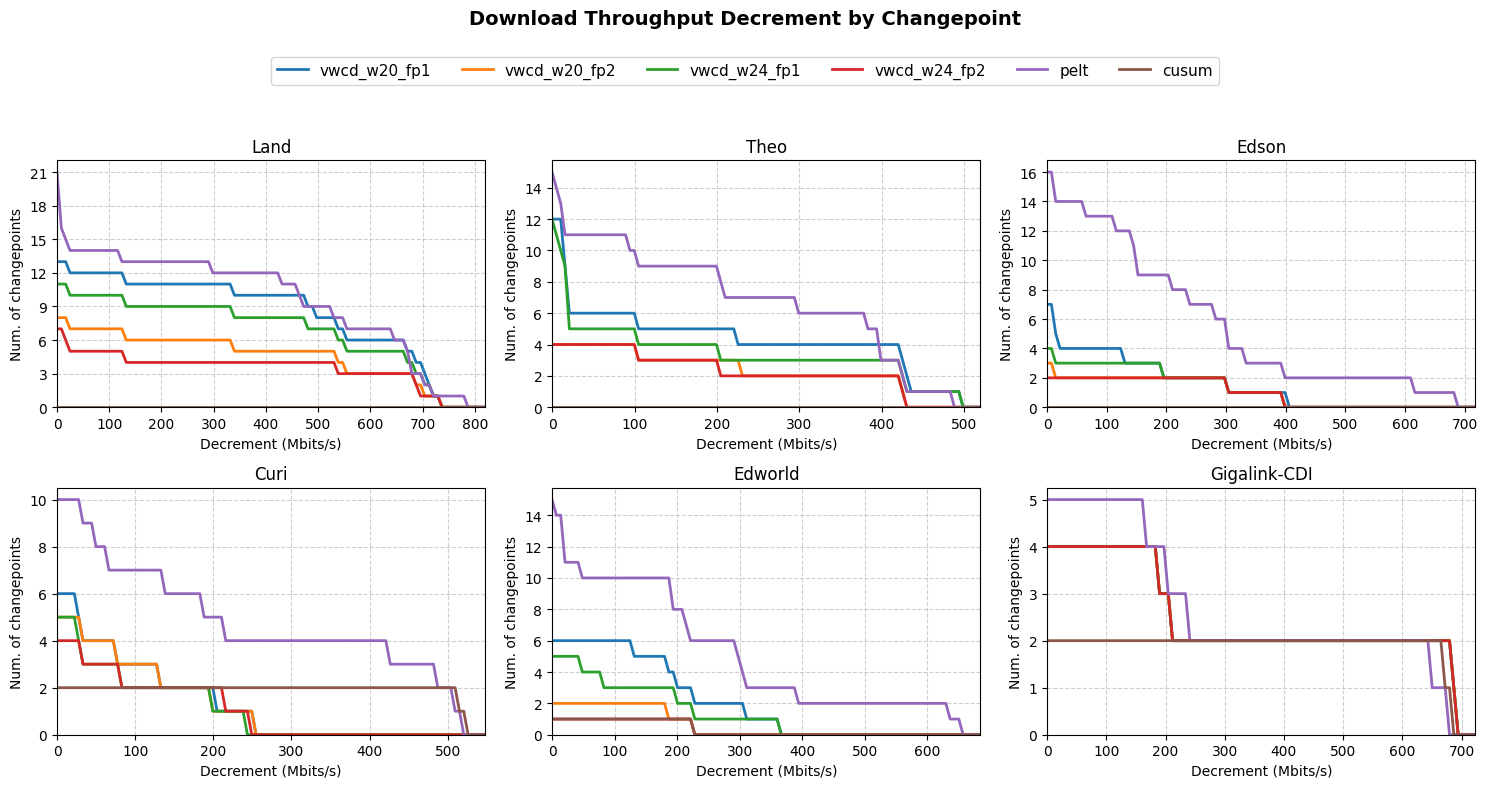

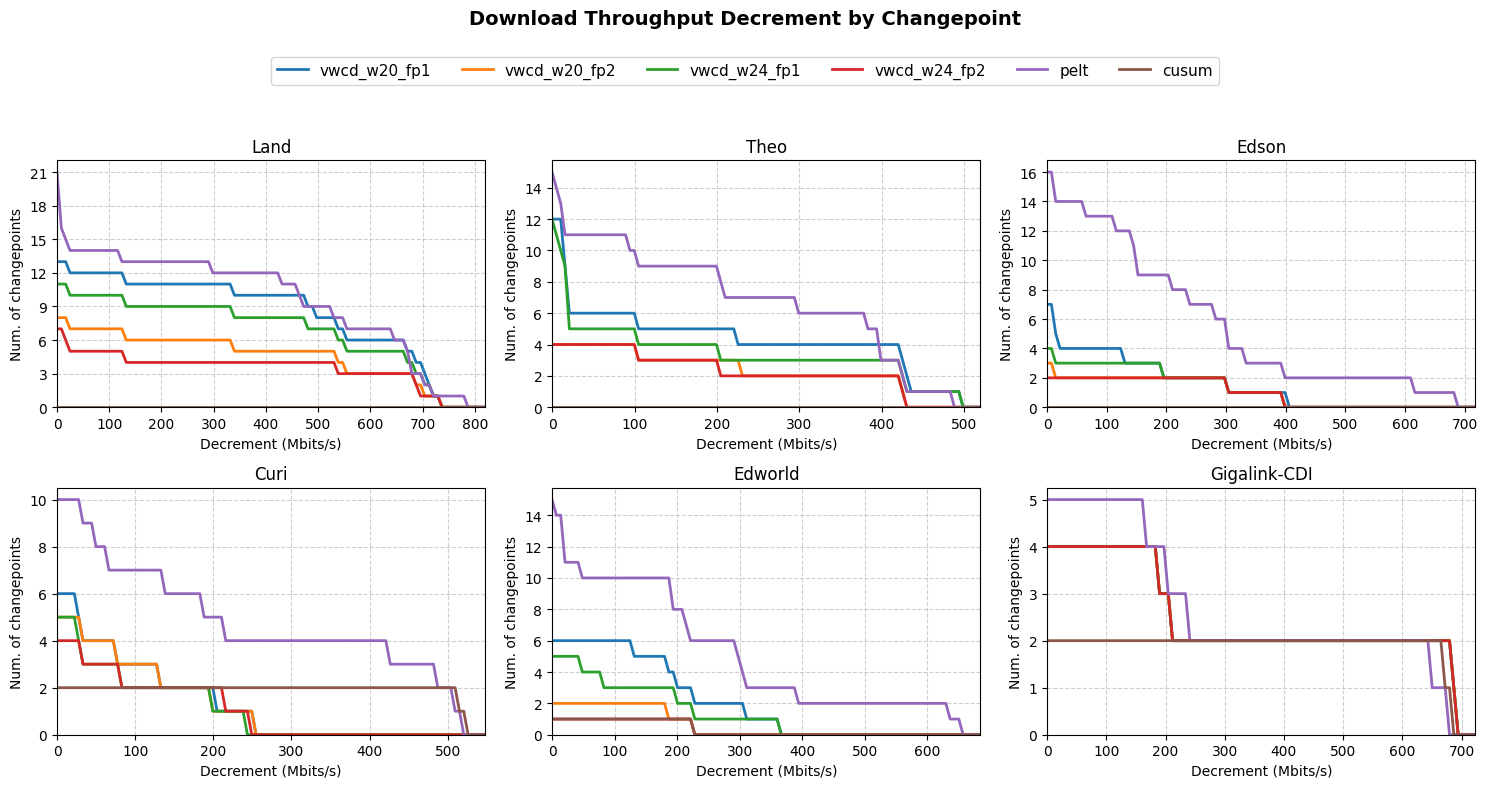

In [60]:
# 1. Parâmetros globais
scenario = "NDT"
lista_methods = ["vwcd_w20_fp1","vwcd_w20_fp2", "vwcd_w24_fp1","vwcd_w24_fp2", 'pelt', 'cusum']
# lista_methods = ["vwcd_w20_fp1","vwcd_w24_fp2", 'pelt', 'cusum']
threshold = 0.95
ref_metric = "rtt_down"
target_clients = ['Land', 'Theo', 'Edson', 'Curi', 'Edworld', 'Gigalink-CDI']

# 2. Pipeline: Executa a extração e os filtros para cada método dinamicamente
df_features_dict = {}

for method in lista_methods:
    # Extrai os dados do método atual
    df_raw = feature_extraction(scenario, method, threshold, ref_metric)

    # Aplica os filtros (garantindo que não dê erro se o DF vier vazio)
    if not df_raw.empty:
        df_filtered = filtros(df_raw)
        # Armazena no dicionário usando o nome do método como chave
        df_features_dict[method] = df_filtered

# 3. Gerar o gráfico com o dicionário de dados prontos
plot_qos_deg_profile_dynamic(
    df_features_dict, target_clients, metric="d_tp_down"
)
plot_qos_deg_profile_dynamic(
    df_features_dict, target_clients, metric="d_tp_down"
)